# 11 JUNE 2026

In [17]:
import os
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Images from Dataset

In [2]:
train_dir = r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Data\Covid19-dataset\train"
test_dir = r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Data\Covid19-dataset\test"

train_dataset = image_dataset_from_directory(train_dir,image_size=(224,224),batch_size=32,shuffle=True)
test_dataset = image_dataset_from_directory(test_dir,image_size=(224,224),batch_size=32,shuffle=True)

Found 251 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


In [3]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [5]:
for images, labels in train_dataset:
    print(images.shape)
    print(labels.shape)
    break

(32, 224, 224, 3)
(32,)


In [ ]:
classes = os.listdir(train_dir)
counts = []

for cls in classes:
    print(cls)
    counts.append(len(os.listdir(os.path.join(train_dir,cls))))

print(dict(zip(classes, counts)))

#Found 251 files belonging to 3 classes.

Covid
Normal
Viral Pneumonia
{'Covid': 111, 'Normal': 70, 'Viral Pneumonia': 70}


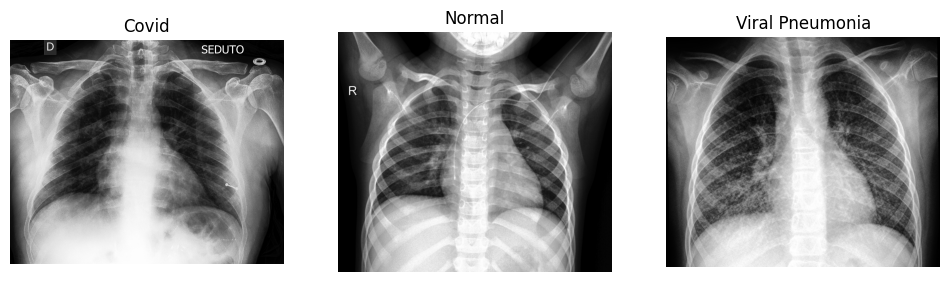

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for idx, cls in enumerate(classes):
    img_path = os.path.join(
                                train_dir,
                                cls,
                                os.listdir(os.path.join(train_dir, cls))[0]
                            )

    img = Image.open(img_path)

    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(cls)
    axes[idx].axis('off')

plt.show()

# Data Augmentation for Class Imbalance

In [22]:
IMG_SIZE = (224, 224)
data_argumentation = ImageDataGenerator(
                                    rescale=1./255,  # Normalize pixel value
                                    rotation_range=20,      # Rotation
                                    width_shift_range=0.1,
                                    height_shift_range=0.1,
                                    zoom_range=0.15,
                                    horizontal_flip=True,   # Flip
                                    brightness_range=[0.8, 1.2],  # Brightness jitter
                                    fill_mode='nearest'
                                )

train_generator = data_argumentation.flow_from_directory(
                                                            train_dir,
                                                            target_size=IMG_SIZE,
                                                            batch_size=32,
                                                            class_mode='categorical'
                                                        )

Found 251 images belonging to 3 classes.


In [30]:
images, labels = next(train_generator)

print("Shape:", images.shape)
print("Min Pixel:", images.min())
print("Max Pixel:", images.max())

Shape: (32, 224, 224, 3)
Min Pixel: 0.0
Max Pixel: 1.0


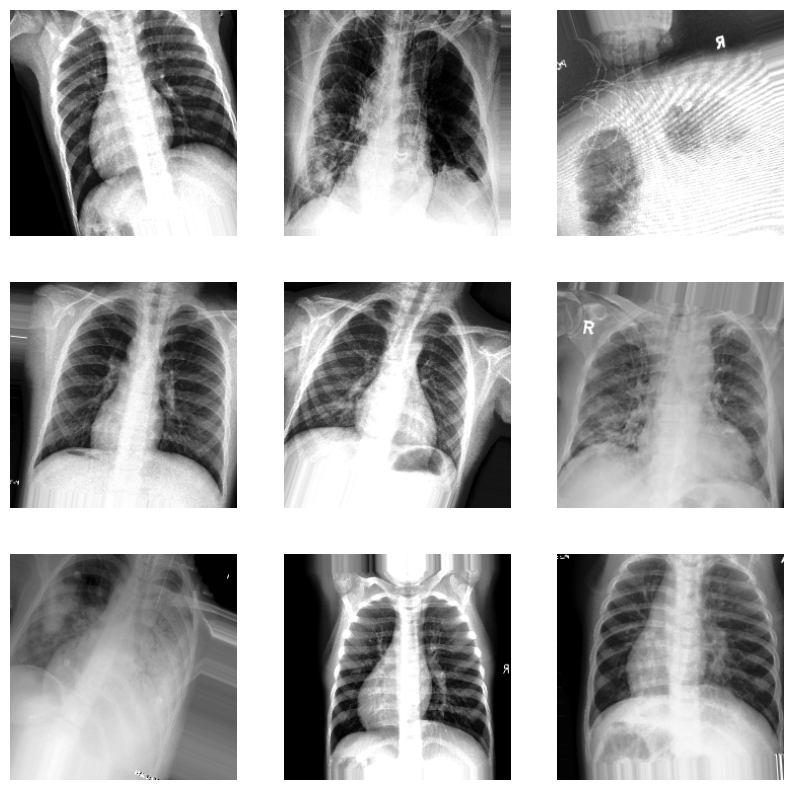

In [ ]:
# Check whether Data augmentation is applied
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()